Found subdirectories (classes): ['single-line', 'zig-zag', 'cross', 'scratch', 'double-line', 'wave', 'Diagonal']
Found 50 files belonging to 7 classes.
Dataset created with 7 classes: ['Diagonal', 'cross', 'double-line', 'scratch', 'single-line', 'wave', 'zig-zag']
Total batches: 2


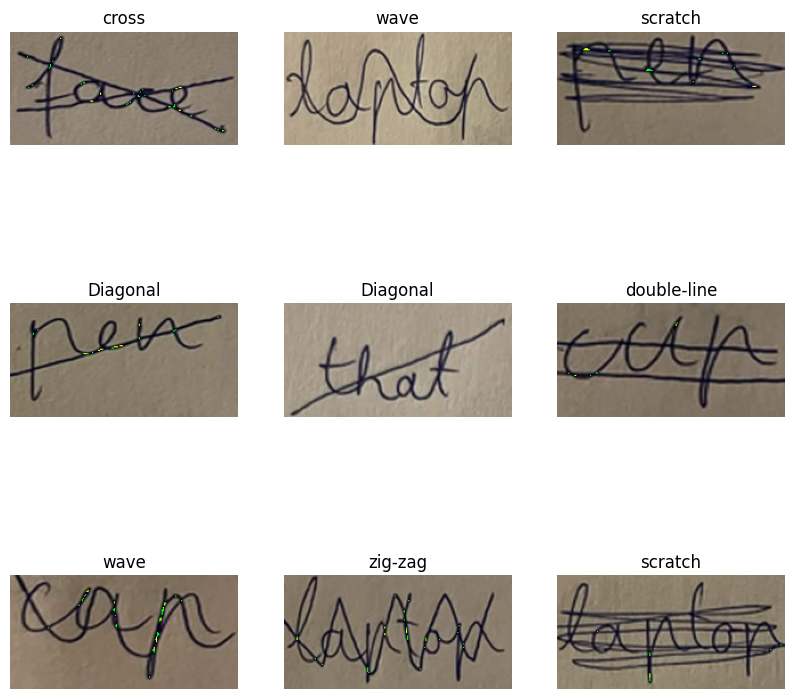

In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

dataset_path = '/content/drive/MyDrive/img/'

if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found.")
else:
    subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    if not subdirs:
        print(f"Error: No subdirectories found in '{dataset_path}'. Please ensure your images are organized into subfolders representing classes.")
    else:
        print(f"Found subdirectories (classes): {subdirs}")

        try:
            image_height = 100
            image_width = 200
            batch_size = 32

            dataset = tf.keras.utils.image_dataset_from_directory(
                dataset_path,
                labels='inferred',
                label_mode='categorical',
                image_size=(image_height, image_width),
                interpolation='lanczos3',
                batch_size=batch_size,
                shuffle=True,
                seed=42
            )

            print(f"Dataset created with {len(dataset.class_names)} classes: {dataset.class_names}")
            print(f"Total batches: {len(dataset)}")

            plt.figure(figsize=(10, 10))
            for images, labels in dataset.take(1):
                for i in range(min(9, len(images))):
                    ax = plt.subplot(3, 3, i + 1)
                    plt.imshow(images[i].numpy().astype("uint8"))
                    predicted_class_index = np.argmax(labels[i].numpy())
                    plt.title(dataset.class_names[predicted_class_index])
                    plt.axis("off")
            plt.show()

        except Exception as e:
            print(f"An error occurred while creating the dataset: {e}")
